In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Strucuture explanation:

# |-models/
#   |model_approach_i/
#     |-model_approach_foldj_last.pth
#     |-model_approach_foldj.json
#     |-model_approach_foldj_best.pth
#     |-arch.png
#   |summary.csv

In [ ]:
import os
model_path='/content/drive/MyDrive/kaggle_rsna_problem/artifacts/models/model_approach_2'
if not os.path.exists(model_path):
  os.makedirs(model_path)

In [ ]:
import os
os.listdir(os.path.join('/content/drive/MyDrive/kaggle_rsna_problem/artifacts/models/model_approach_2'))

['model_approach_2_fold0_best.pth',
 'model_approach_2_fold0_last.pth',
 'model_approach_2_fold0.json']

##  ============== Model Approach 1 ==============

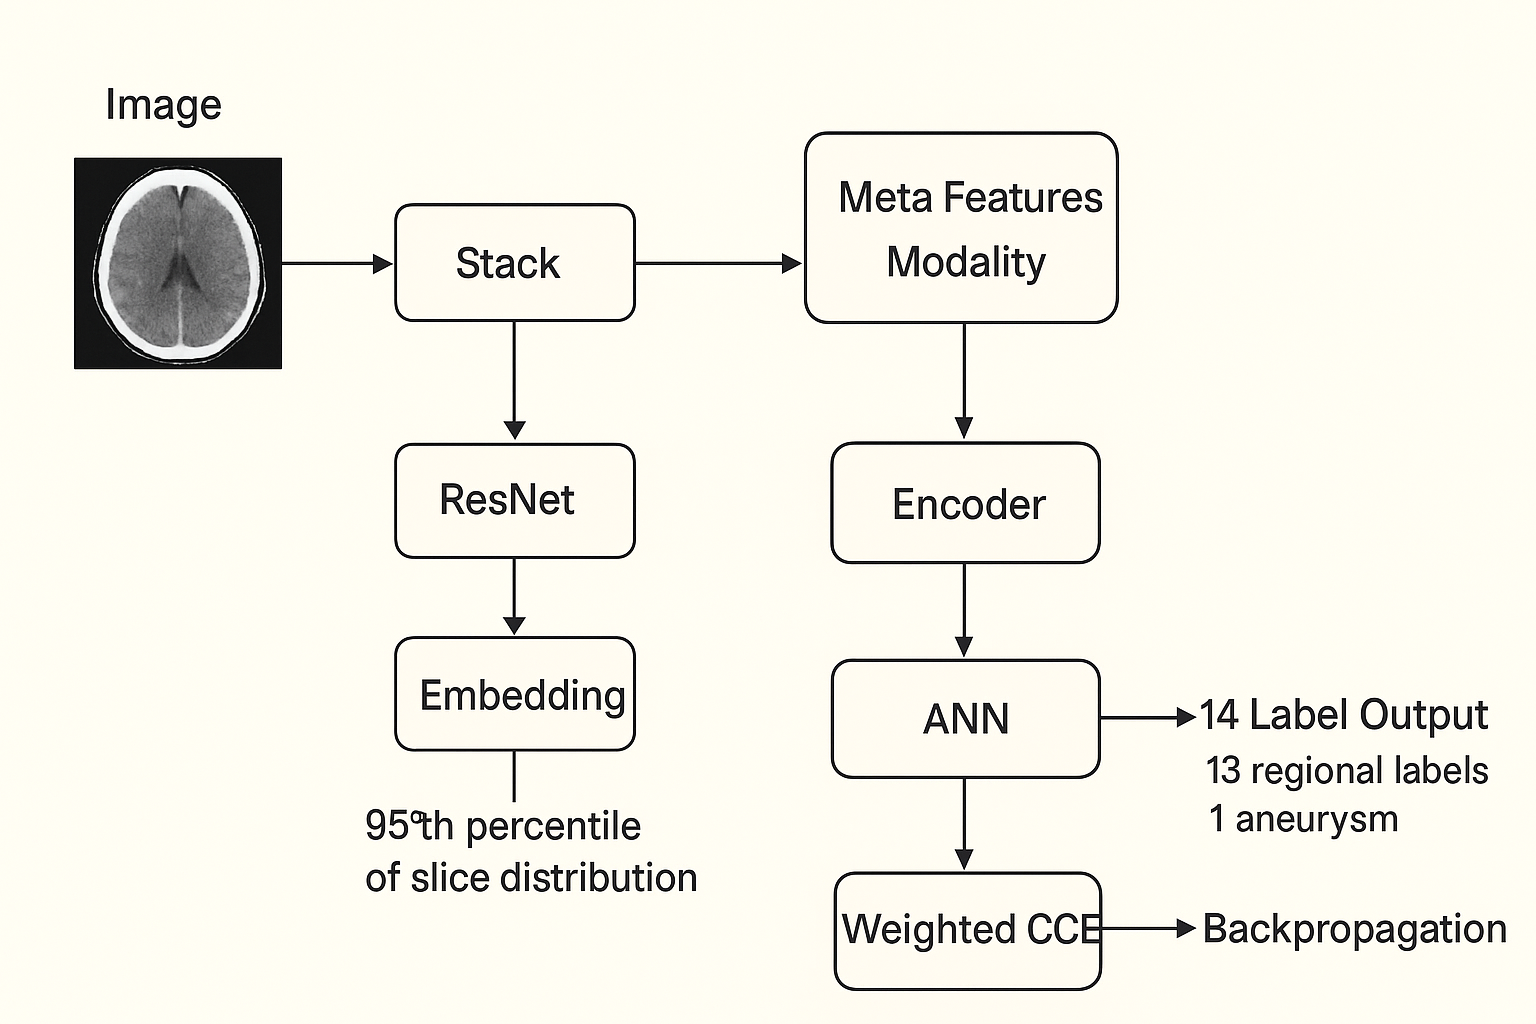


In [ ]:
"""
citation for using radimagenet pretrained model

"""
"""
@article{doi:10.1148/ryai.210315,
author = {Mei, Xueyan and Liu, Zelong and Robson, Philip M. and Marinelli, Brett and Huang, Mingqian and Doshi, Amish and Jacobi, Adam and Cao, Chendi and Link, Katherine E. and Yang, Thomas and Wang, Ying and Greenspan, Hayit and Deyer, Timothy and Fayad, Zahi A. and Yang, Yang},
title = {RadImageNet: An Open Radiologic Deep Learning Research Dataset for Effective Transfer Learning},
journal = {Radiology: Artificial Intelligence},
volume = {0},
number = {ja},
pages = {e210315},
year = {0},
doi = {10.1148/ryai.210315},

URL = {
        https://doi.org/10.1148/ryai.210315

},
eprint = {
        https://doi.org/10.1148/ryai.210315
}
}
"""

'\n@article{doi:10.1148/ryai.210315,\nauthor = {Mei, Xueyan and Liu, Zelong and Robson, Philip M. and Marinelli, Brett and Huang, Mingqian and Doshi, Amish and Jacobi, Adam and Cao, Chendi and Link, Katherine E. and Yang, Thomas and Wang, Ying and Greenspan, Hayit and Deyer, Timothy and Fayad, Zahi A. and Yang, Yang},\ntitle = {RadImageNet: An Open Radiologic Deep Learning Research Dataset for Effective Transfer Learning},\njournal = {Radiology: Artificial Intelligence},\nvolume = {0},\nnumber = {ja},\npages = {e210315},\nyear = {0},\ndoi = {10.1148/ryai.210315},\n\nURL = {\n        https://doi.org/10.1148/ryai.210315\n\n},\neprint = {\n        https://doi.org/10.1148/ryai.210315\n}\n}\n'

In [ ]:
last_entry_embedding='/content/drive/MyDrive/kaggle_rsna_problem/artifacts/models/model_approach_1/embeddings/last_entry_embedding.txt'
series_data='/content/drive/MyDrive/kaggle_rsna_problem/artifacts/preprocessor/preprocessor_approach_1/data/series'


In [ ]:
with open(last_entry_embedding,'r') as f:
  embeded=f.read()
  print(f'Total embeddings generated: {embeded}')

Total embeddings generated: 4081


In [ ]:
import os
series=os.listdir(series_data)
final_series=[]
for scan in series:
  if(scan.endswith('.npy')):
    final_series.append(scan)

final_series.sort()
print(f'Total available scans with z index sorting: {len(final_series)}')

Total available scans with z index sorting: 4081


In [ ]:
!pip show monai

In [ ]:
!pip install monai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 39.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 766.6/766.6 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 124.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 99.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 63.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 42.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150.1/150.1 MB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import os
embedding_data_path = "/content/drive/MyDrive/kaggle_rsna_problem/artifacts/models/model_approach_1/embeddings/data"
len(set(os.listdir(embedding_data_path)))

4082

In [ ]:
"""
Embedding generator with augmentation using RadImageNet ResNet50
"""

import torch
import torch.nn as nn
import numpy as np
import os
import monai
from monai.transforms import (
    Compose,RandGaussianNoise, RandScaleIntensity, RandShiftIntensity
)

# Paths
radimagenet_path = "/content/drive/MyDrive/kaggle_rsna_problem/artifacts/models/model_approach_1/RadImageNet_pytorch/ResNet50.pt"
embedding_data_path = "/content/drive/MyDrive/kaggle_rsna_problem/artifacts/models/model_approach_1/embeddings/data"
os.makedirs(embedding_data_path, exist_ok=True)

def get_feature_extractor():
    resnet = monai.networks.nets.resnet50(spatial_dims=2, n_input_channels=3)

    state_dict = torch.load(radimagenet_path, map_location="cpu")
    # checkpoint wrapped like {"state_dict": ...}
    if "state_dict" in state_dict:
        state_dict = state_dict["state_dict"]

    # remove "backbone." prefix
    new_state_dict = {}
    for k, v in state_dict.items():
        new_k = k.replace("backbone.", "")  # strip prefix
        new_state_dict[new_k] = v

    # load into resnet
    resnet.load_state_dict(new_state_dict, strict=False)

    feature_extractor = nn.Sequential(*list(resnet.children())[:-1])  # remove fc
    feature_extractor.eval()
    return feature_extractor


# Init embedder
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
Embedder = get_feature_extractor().to(device)

# Define augmentation pipeline
augment = Compose([
    RandGaussianNoise(prob=0.2, mean=0.0, std=0.01),               # scanner noise
    RandScaleIntensity(factors=0.1, prob=0.3),                     # intensity scaling
    RandShiftIntensity(offsets=0.1, prob=0.3),                     # intensity shifting
])

In [ ]:

from torchsummary import summary

summary(Embedder, input_size=(3, 224, 224), device="cuda" if torch.cuda.is_available() else "cpu")


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 224, 224]           9,408
       BatchNorm2d-2         [-1, 64, 224, 224]             128
              ReLU-3         [-1, 64, 224, 224]               0
         MaxPool2d-4         [-1, 64, 112, 112]               0
            Conv2d-5         [-1, 64, 112, 112]           4,096
       BatchNorm2d-6         [-1, 64, 112, 112]             128
              ReLU-7         [-1, 64, 112, 112]               0
            Conv2d-8         [-1, 64, 112, 112]          36,864
       BatchNorm2d-9         [-1, 64, 112, 112]             128
             ReLU-10         [-1, 64, 112, 112]               0
           Conv2d-11        [-1, 256, 112, 112]          16,384
      BatchNorm2d-12        [-1, 256, 112, 112]             512
           Conv2d-13        [-1, 256, 112, 112]          16,640
      BatchNorm2d-14        [-1, 256, 1

In [ ]:
# example embedding
embedding=Embedder(torch.tensor(np.random.rand(1, 3, 224, 224), dtype=torch.float32).to(device))
print(embedding.shape)

torch.Size([1, 2048, 1, 1])


In [ ]:
# batch generation

BATCH_SIZE = 1000 # per series

for i in range(BATCH_SIZE):

    # read last processed entry
    with open(last_entry_embedding, "r") as f:
        last_entry = int(f.read())

    curr = int(last_entry)

    if curr >= len(final_series):
        print("✅ All series processed. Go and train your model 🫠")
        break

    # series path
    series_path = final_series[curr]   # "series_id.npy"
    series_id = os.path.splitext(os.path.basename(series_path))[0]

    # load slices
    slices = np.load(f"{series_data}/{series_path}")  # (num_slices, 224, 224)

    embeddings = []
    with torch.no_grad():
        for s in slices:
            # augment slice (still single-channel)
            s_aug = augment(s[np.newaxis, :, :])  # (1, H, W)

            # expand to 3 channels (grayscale → RGB-like)
            img = np.repeat(s_aug, 3, axis=0)  # (3, 224, 224)
            img = torch.tensor(img, dtype=torch.float32).unsqueeze(0).to(device)  # (1, 3, 224, 224)

            # forward pass
            feat = Embedder(img)  # (1, 2048, 1, 1)
            feat = torch.flatten(feat, 1)  # (1, 2048)

            embeddings.append(feat.cpu().numpy())

    # stack → (num_slices, 2048)
    embeddings = np.vstack(embeddings)
    print(f"✅ Generated embeddings for series {series_id} → {embeddings.shape}")

    # save embedding
    out_path = os.path.join(embedding_data_path, f"{series_id}.npy")
    np.save(out_path, embeddings)
    print(f"✅ Saved embeddings for series {series_id} at {out_path}")

    # prin log
    print(f"🚀Processed {curr + 1}/{len(final_series)} series")
    print(f'🚀Processed [{i+1}/{BATCH_SIZE}] series')

    # update progress
    curr += 1
    with open(last_entry_embedding, "w") as f:
        f.write(str(curr))
with open(last_entry_embedding,'r') as f:
  embeded=f.read()
  print(f'Total embeddings generated allover: {embeded}')

In [ ]:
import numpy as np
r_e=np.load(os.path.join(embedding_data_path,'1.2.826.0.1.3680043.8.498.10009383108068795488741533244914370182.npy'))
print(f'Raw embedding shape: {r_e.shape}')

Raw embedding shape: (224, 2048)


In [ ]:
import torch
import os
from torch.utils.data import Dataset
import pandas as pd
import numpy as np

SEQ_LEN = 800
EMB_DIM = 2048

def embedding_resizer(raw_embedding: np.ndarray, seq_len: int = SEQ_LEN):
    """
    Resize embeddings to fixed length (seq_len, EMB_DIM).
    Also returns an attention mask (1 for real slices, 0 for padding).
    """
    n_slices = raw_embedding.shape[0]

    # Case 1: Too short → pad
    if n_slices < seq_len:
        pad_len = seq_len - n_slices
        pad = np.zeros((pad_len, raw_embedding.shape[1]), dtype=raw_embedding.dtype)
        resized = np.concatenate([raw_embedding, pad], axis=0)
        mask = np.concatenate([np.ones(n_slices), np.zeros(pad_len)])

    # Case 2: Too long → sample evenly
    elif n_slices > seq_len:
        indices = np.linspace(0, n_slices - 1, seq_len).astype(int)
        resized = raw_embedding[indices]
        mask = np.ones(seq_len)

    # Case 3: Exact length
    else:
        resized = raw_embedding
        mask = np.ones(seq_len)

    return resized, mask


class AnuerysmDataset(Dataset):
    """
    A custom dataloader for aneurysm detection from slice embeddings.
    """

    def __init__(self, csv_file_path, embedding_path):
        super(AnuerysmDataset, self).__init__()

        self.csv_file_path = csv_file_path
        self.df = pd.read_csv(self.csv_file_path)

        print('📑 dataloader_init....')

        # ensure SeriesInstanceUID is string
        self.df['SeriesInstanceUID'] = self.df['SeriesInstanceUID'].astype(str)

        # list all .npy embedding files
        all_files = sorted(os.listdir(embedding_path))
        self.embedding_directory = embedding_path

        # keep only embeddings that exist in the CSV
        self.embedding_files = [
            f for f in all_files
            if os.path.splitext(os.path.basename(f))[0] in self.df['SeriesInstanceUID'].values
        ]

        print(f'📁 Found examples/scans: {len(self.embedding_files)}')

    def __len__(self):
        return len(self.embedding_files)

    def __getitem__(self, idx):
        # get file name
        file_name = self.embedding_files[idx]
        series_id = os.path.splitext(os.path.basename(file_name))[0]

        # load embedding
        embedding_path = os.path.join(self.embedding_directory, file_name)
        raw_embedding = np.load(embedding_path)   # shape: (n_slices, EMB_DIM)
        embedding, mask = embedding_resizer(raw_embedding, SEQ_LEN)

        embedding = torch.tensor(embedding, dtype=torch.float32)   # (SEQ_LEN, EMB_DIM)
        mask = torch.tensor(mask, dtype=torch.float32)             # (SEQ_LEN,)

        # get labels
        row = self.df[self.df['SeriesInstanceUID'] == series_id].iloc[0]

        label_cols = [
            'Left Infraclinoid Internal Carotid Artery',
            'Right Infraclinoid Internal Carotid Artery',
            'Left Supraclinoid Internal Carotid Artery',
            'Right Supraclinoid Internal Carotid Artery',
            'Left Middle Cerebral Artery',
            'Right Middle Cerebral Artery',
            'Anterior Communicating Artery',
            'Left Anterior Cerebral Artery',
            'Right Anterior Cerebral Artery',
            'Left Posterior Communicating Artery',
            'Right Posterior Communicating Artery',
            'Basilar Tip',
            'Other Posterior Circulation',
            'Aneurysm Present'
        ]

        labels = row[label_cols].values.astype(np.float32)
        labels = torch.tensor(labels, dtype=torch.float32)  # multi-label vector

        return embedding, mask, labels


In [ ]:
# use pos weights for class imbalance
import torch
import pandas as pd

train_csv_path = "/content/drive/MyDrive/kaggle_rsna_problem/artifacts/preprocessor/preprocessor_approach_1/data/train_z.csv"
df = pd.read_csv(train_csv_path)

label_cols = [
    'Left Infraclinoid Internal Carotid Artery',
    'Right Infraclinoid Internal Carotid Artery',
    'Left Supraclinoid Internal Carotid Artery',
    'Right Supraclinoid Internal Carotid Artery',
    'Left Middle Cerebral Artery',
    'Right Middle Cerebral Artery',
    'Anterior Communicating Artery',
    'Left Anterior Cerebral Artery',
    'Right Anterior Cerebral Artery',
    'Left Posterior Communicating Artery',
    'Right Posterior Communicating Artery',
    'Basilar Tip',
    'Other Posterior Circulation',
    'Aneurysm Present'
]

# compute ratio of negatives/positives per label
pos_counts = df[label_cols].sum().values
neg_counts = len(df) - pos_counts
pos_weight = torch.tensor(neg_counts / pos_counts, dtype=torch.float32)

print("pos_weight:", pos_weight)


pos_weight: tensor([50.0000, 44.3333, 12.7528, 14.9652, 19.1758, 13.8065, 10.5836, 93.1538,
        71.0000, 47.9600, 41.2069, 35.7200, 33.9714,  1.3211])


In [ ]:
# Transformer approach for training
# Strucuture explanation:

# |-models/
#   |model_approach_i/
#     |-model_approach_foldj_last.pth
#     |-model_approach_foldj.json
#     |-model_approach_foldj_best.pth
#     |-arch.png
#   |summary.csv

# currently j=0, i=2


In [ ]:
import torch
import torch.nn as nn

class AneurysmGRU(nn.Module):
    def __init__(self,
                 input_dim=2048,
                 hidden_dim=512,
                 num_layers=2,
                 num_classes=14,
                 bidirectional=True,
                 dropout=0.3):
        super(AneurysmGRU, self).__init__()

        self.gru = nn.GRU(
            input_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=bidirectional
        )

        self.bidirectional = bidirectional
        self.hidden_dim = hidden_dim

        # Linear head
        out_dim = hidden_dim * (2 if bidirectional else 1)
        self.fc = nn.Sequential(
            nn.Linear(out_dim, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )

    def forward(self, x, mask=None):
        """
        x: (batch, seq_len, input_dim)
        mask: (batch, seq_len)   [1 = real, 0 = pad]
        """
        # GRU forward
        out, _ = self.gru(x)   # (batch, seq_len, hidden_dim*2)

        if mask is not None:
            mask = mask.unsqueeze(-1)  # (batch, seq_len, 1)
            out = out * mask           # zero out padded timesteps

        # Global average pooling (mask-aware)
        if mask is not None:
            summed = torch.sum(out, dim=1)             # (batch, hidden_dim*2)
            counts = torch.sum(mask, dim=1) + 1e-6     # (batch, 1)
            pooled = summed / counts                   # mean pooling
        else:
            pooled = out.mean(dim=1)

        # Classifier
        logits = self.fc(pooled)  # (batch, num_classes)

        return logits


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class WeightedBCEWithLogitsLoss(nn.Module):
    def __init__(self, label_weights=None, pos_weights=None):
        super().__init__()
        self.label_weights = torch.tensor(label_weights).float() if label_weights is not None else None
        if pos_weights is not None:
            if isinstance(pos_weights, np.ndarray):
                self.pos_weights = torch.from_numpy(pos_weights).float()
            elif isinstance(pos_weights, torch.Tensor):
                self.pos_weights = pos_weights.clone().detach().float()
            else:
                raise TypeError(f"pos_weights must be np.ndarray or torch.Tensor, got {type(pos_weights)}")
        else:
            self.pos_weights = None



    def forward(self, logits, targets):
        # pos_weight only affects positive terms
        loss = F.binary_cross_entropy_with_logits(
            logits,
            targets,
            reduction="none",
            pos_weight=self.pos_weights.to(logits.device) if self.pos_weights is not None else None
        )
        # shape: (batch, num_labels)

        if self.label_weights is not None:
            loss = loss * self.label_weights.to(logits.device)

        return loss.mean()


In [ ]:
# 0.59 auc Training code
import os
import json
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from sklearn.metrics import roc_auc_score
import numpy as np

def train_model(model, train_dataset, val_dataset, device,
                approach_name="model_approach_2", fold=0,
                batch_size=8, epochs=1, lr=1e-4, weight_decay=1e-5,
                early_stop_patience=100,
                base_dir="/content/drive/MyDrive/kaggle_rsna_problem/artifacts/models"):

    # -------- Paths -------- #
    model_dir = os.path.join(base_dir, approach_name)
    os.makedirs(model_dir, exist_ok=True)
    best_model_path = os.path.join(model_dir, f"{approach_name}_fold{fold}_best.pth")
    last_model_path = os.path.join(model_dir, f"{approach_name}_fold{fold}_last.pth")
    meta_path = os.path.join(model_dir, f"{approach_name}_fold{fold}.json")
    plot_path = os.path.join(model_dir, "plot_training.png")

    # -------- Initialize -------- #
    best_val_loss = float("inf")
    best_comp = 0.0
    history = {"train_loss": [], "val_loss": [], "val_auc": [], "per_label_auc": [], "lrs": [], "comp_metric": []}
    prev_epochs = 0
    no_improve_epochs = 0

    # -------- Model + Optimizer + Scheduler -------- #
    model = model.to(device)
    pos_weights = torch.tensor([
        50.0000, 44.3333, 12.7528, 14.9652, 19.1758, 13.8065, 10.5836, 93.1538,
        71.0000, 47.9600, 41.2069, 35.7200, 33.9714,  1.3211
    ], device=device)
    # Try inverse weights to see performance on other labels also
    # auc_ = np.array([0.85, 0.62, 0.54, 0.52, 0.58, 0.57, 0.61, 0.53, 0.63, 0.62, 0.55, 0.47, 0.69, 0.57])
    # weights_ = 1 - auc_  # simple heuristic
    # weights_ = weights_ / weights_.sum()  # normalize
    # # criterion = nn.BCEWithLogitsLoss(weight=torch.tensor(weights).to(device))
    label_weights = [1]*13+[13]
    label_weights=torch.tensor(label_weights).to(device)



    criterion = WeightedBCEWithLogitsLoss(
        label_weights=label_weights,
        pos_weights=pos_weights
    )
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=3, verbose=True
    )

    # -------- Resume if available -------- #
    if os.path.exists(last_model_path):
        print(f"⏪ Resuming from checkpoint {last_model_path}")
        checkpoint = torch.load(last_model_path, map_location=device)
        model.load_state_dict(checkpoint["model_state"])
        optimizer.load_state_dict(checkpoint["optimizer_state"])
        best_comp_metric=max(map(lambda x:float(x),list(checkpoint['history']["comp_metric"])))
        history = checkpoint["history"]
        prev_epochs = checkpoint["epoch"]
        print(f"🔄 Resumed at epoch {prev_epochs}, best_meteric={best_comp_metric:.4f}")
        best_comp=best_comp_metric

    # -------- Dataloaders -------- #
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

    # -------- Label weights for weighted AUC -------- #
    auc_weights = np.array([1] * 13 + [13])

    for epoch in range(epochs):
        # ---- Train ---- #
        model.train()
        train_loss = 0.0
        grad_norms = []

        for embeddings, masks, labels in train_loader:
            embeddings, masks, labels = embeddings.to(device), masks.to(device), labels.to(device)

            optimizer.zero_grad()
            logits = model(embeddings, masks)
            loss = criterion(logits, labels)
            loss.backward()

            # Log gradient norm
            total_norm = torch.norm(torch.stack([
                p.grad.detach().data.norm(2) for p in model.parameters() if p.grad is not None
            ]), 2).item()
            grad_norms.append(total_norm)

            optimizer.step()
            train_loss += loss.item() * embeddings.size(0)

        avg_train_loss = train_loss / len(train_loader.dataset)

        # ---- Validation ---- #
        model.eval()
        val_loss = 0.0
        all_labels, all_probs = [], []

        with torch.no_grad():
            for embeddings, masks, labels in val_loader:
                embeddings, masks, labels = embeddings.to(device), masks.to(device), labels.to(device)
                logits = model(embeddings, masks)
                loss = criterion(logits, labels)
                val_loss += loss.item() * embeddings.size(0)

                probs = torch.sigmoid(logits).detach().cpu()
                all_probs.append(probs)
                all_labels.append(labels.cpu())

        avg_val_loss = val_loss / len(val_loader.dataset)
        scheduler.step(avg_val_loss)

        # ---- Compute per-label AUCs ---- #
        all_probs = torch.cat(all_probs).numpy()
        all_labels = torch.cat(all_labels).numpy()

        per_label_auc = []
        for j in range(all_labels.shape[1]):
            try:
                auc_j = roc_auc_score(all_labels[:, j], all_probs[:, j])
            except ValueError:
                auc_j = np.nan
            per_label_auc.append(auc_j)

        per_label_auc = np.array(per_label_auc)
        valid_mask = ~np.isnan(per_label_auc)
        weighted_auc = np.average(per_label_auc[valid_mask], weights=auc_weights[valid_mask])

        # ---- RSNA Competition Metric ---- #
        auc_ap = per_label_auc[13]                     # Aneurysm Present
        auc_subtypes = np.nanmean(per_label_auc[:13])  # mean of first 13
        comp_metric = 0.5 * (auc_ap + auc_subtypes)

        # ---- Append History ---- #
        current_lr = optimizer.param_groups[0]["lr"]
        history["train_loss"].append(float(avg_train_loss))
        history["val_loss"].append(float(avg_val_loss))
        history["val_auc"].append(float(weighted_auc))
        history["per_label_auc"].append([float(x) if not np.isnan(x) else None for x in per_label_auc])
        history["lrs"].append(current_lr)
        history["comp_metric"].append(float(comp_metric))

        current_epoch = prev_epochs + epoch + 1
        print(f"Epoch [{current_epoch}] "
              f"Train Loss: {avg_train_loss:.4f} | "
              f"Val Loss: {avg_val_loss:.4f} | "
              f"Val Weighted AUC: {weighted_auc:.4f} | "
              f"Comp Metric: {comp_metric:.4f} | "
              f"LR: {current_lr:.6f} | "
              f"GradNorm (avg): {np.mean(grad_norms):.2f}")

        print(f"🔎 Per-label AUC: {[round(a, 3) if a is not None else None for a in history['per_label_auc'][-1]]}")

        # ---- Save Best (based on comp metric) ---- #
        if comp_metric > best_comp:
            best_comp = comp_metric
            torch.save({
                "epoch": current_epoch,
                "model_state": model.state_dict(),
                "optimizer_state": optimizer.state_dict(),
                "best_val_loss": best_val_loss,
                "history": history
            }, best_model_path)
            print(f"✅ Saved BEST model (Comp Metric={best_comp:.4f}) at {best_model_path}")
            no_improve_epochs = 0
        else:
            no_improve_epochs += 1

        # ---- Save Last ---- #
        torch.save({
            "epoch": current_epoch,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "best_val_loss": best_val_loss,
            "history": history
        }, last_model_path)

        # ---- Save Metadata ---- #
        meta = {
            "approach": approach_name,
            "fold": fold,
            "epochs": current_epoch,
            "batch_size": batch_size,
            "lr": lr,
            "weight_decay": weight_decay,
            "best_val_loss": best_val_loss,
            "best_comp_metric": best_comp,
            "history": history,
            "last_comp_metric": comp_metric,
        }
        with open(meta_path, "w") as f:
            json.dump(meta, f, indent=2)

        # ---- Early stopping ---- #
        if no_improve_epochs >= early_stop_patience:
            print(f"⏹ Early stopping triggered at epoch {current_epoch}")
            break

    # -------- Plot Curves -------- #
    if len(history["train_loss"]) > 0:
        plt.figure(figsize=(10, 6))
        epochs_range = range(1, len(history["train_loss"]) + 1)

        plt.subplot(2, 1, 1)
        plt.plot(epochs_range, history["train_loss"], label="Train Loss")
        plt.plot(epochs_range, history["val_loss"], label="Validation Loss")
        plt.ylabel("Loss")
        plt.legend()
        plt.grid(True)

        plt.subplot(2, 1, 2)
        plt.plot(epochs_range, history["val_auc"], label="Val Weighted AUC")
        plt.plot(epochs_range, history["comp_metric"], label="Comp Metric")
        plt.xlabel("Epoch")
        plt.ylabel("Score")
        plt.legend()
        plt.grid(True)

        plt.tight_layout()
        plt.savefig(plot_path)
        plt.close()
        print(f"📈 Saved training curve at {plot_path}")
    else:
        print("⚠️ No history data found, skipping plot.")

    return best_model_path, last_model_path


In [ ]:
import torch

# ==== Paths ====
# train_test by csv files

train_csv_path = "/content/drive/MyDrive/kaggle_rsna_problem/artifacts/preprocessor/preprocessor_approach_1/data/train_z.csv"
test_csv_path = "/content/drive/MyDrive/kaggle_rsna_problem/artifacts/preprocessor/preprocessor_approach_1/data/test_z.csv"
embedding_dir = "/content/drive/MyDrive/kaggle_rsna_problem/artifacts/models/model_approach_1/embeddings/data"
model_dir = "/content/drive/MyDrive/kaggle_rsna_problem/artifacts/models/"

# ==== Device ====
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("⚡ Using device:", device)

# ==== Dataset & Split ====
train_dataset = AnuerysmDataset(csv_file_path=train_csv_path, embedding_path=embedding_dir)
val_dataset = AnuerysmDataset(csv_file_path=test_csv_path, embedding_path=embedding_dir)

print(f"📊 Train: {len(train_dataset)} | Val: {len(val_dataset)}")



⚡ Using device: cuda
📑 dataloader_init....
📁 Found examples/scans: 3672
📑 dataloader_init....
📁 Found examples/scans: 409
📊 Train: 3672 | Val: 409


In [ ]:
train_csv_path = "/content/drive/MyDrive/kaggle_rsna_problem/artifacts/preprocessor/preprocessor_approach_1/data/train_z.csv"
test_csv_path = "/content/drive/MyDrive/kaggle_rsna_problem/artifacts/preprocessor/preprocessor_approach_1/data/test_z.csv"
import pandas as pd
len(pd.read_csv(train_csv_path)),len(pd.read_csv(test_csv_path))

(3672, 409)

In [ ]:
# ==== Model ====
model = AneurysmGRU(
    input_dim=2048,
    hidden_dim=800,
    num_layers=4,
    num_classes=14,
    bidirectional=True,
    dropout=0.4
)


In [ ]:
# ==== Training ====
best_model, last_model = train_model(
    model=model,
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    device=device,
    approach_name="model_approach_2",
    fold=0,
    batch_size=8,
    epochs=5,
    lr=1e-4,
    base_dir=model_dir
)

print("✅ Training finished.")
print("Best model saved at:", best_model)
print("Last model saved at:", last_model)

/tmp/ipython-input-2134947789.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.label_weights = torch.tensor(label_weights).float() if label_weights is not None else None


⏪ Resuming from checkpoint /content/drive/MyDrive/kaggle_rsna_problem/artifacts/models/model_approach_2/model_approach_2_fold0_last.pth
🔄 Resumed at epoch 30, best_meteric=0.5881
Epoch [31] Train Loss: 0.0905 | Val Loss: 0.0939 | Val Weighted AUC: 0.5731 | Comp Metric: 0.5731 | LR: 0.000050 | GradNorm (avg): 0.09
🔎 Per-label AUC: [0.718, 0.545, 0.55, 0.501, 0.569, 0.565, 0.621, 0.482, 0.672, 0.573, 0.511, 0.446, 0.671, 0.575]
Epoch [32] Train Loss: 0.0902 | Val Loss: 0.0947 | Val Weighted AUC: 0.5722 | Comp Metric: 0.5722 | LR: 0.000050 | GradNorm (avg): 0.10
🔎 Per-label AUC: [0.718, 0.549, 0.552, 0.504, 0.571, 0.563, 0.62, 0.482, 0.668, 0.566, 0.507, 0.441, 0.669, 0.574]
Epoch [33] Train Loss: 0.0903 | Val Loss: 0.0950 | Val Weighted AUC: 0.5706 | Comp Metric: 0.5706 | LR: 0.000050 | GradNorm (avg): 0.11
🔎 Per-label AUC: [0.717, 0.558, 0.55, 0.503, 0.572, 0.564, 0.619, 0.487, 0.666, 0.554, 0.499, 0.435, 0.668, 0.573]
Epoch [34] Train Loss: 0.0904 | Val Loss: 0.0955 | Val Weighted AUC: